In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

data = pd.read_csv("data/FRED data.csv")

data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date")

In [2]:
#EDA
data.info()
data.describe()
data.isnull().sum()
data["recession"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   410 non-null    datetime64[ns]
 1   unemployment           410 non-null    float64       
 2   cpi                    410 non-null    float64       
 3   industrial_production  410 non-null    float64       
 4   retail_sales           410 non-null    int64         
 5   consumer_sentiment     410 non-null    float64       
 6   recession              410 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 22.6 KB


recession
0    382
1     28
Name: count, dtype: int64

In [3]:
#Feature Engineering
feature_cols = ["unemployment", "cpi", "industrial_production", "retail_sales", "consumer_sentiment"]

#Lag
for col in feature_cols:
    data[f"{col}_lag1"] = data[col].shift(1)
    data[f"{col}_lag3"] = data[col].shift(3)
    data[f"{col}_lag6"] = data[col].shift(6)

for col in feature_cols:
    data[f"{col}_change"] = data[col].pct_change()

data = data.dropna()

In [4]:
#Training Models
X = data.drop(columns=["date", "recession"])
y = data["recession"]

split = int(len(data) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, lr_pred, zero_division=0))

print("Random Forest")
print(classification_report(y_test, rf_pred, zero_division=0))

print("Gradient Boosting")
print(classification_report(y_test, gb_pred, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        79
           1       0.08      1.00      0.15         2

    accuracy                           0.72        81
   macro avg       0.54      0.85      0.49        81
weighted avg       0.98      0.72      0.81        81

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        79
           1       0.00      0.00      0.00         2

    accuracy                           0.98        81
   macro avg       0.49      0.50      0.49        81
weighted avg       0.95      0.98      0.96        81

Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.71      0.82        79
           1       0.04      0.50      0.08         2

    accuracy                           0.70        81
   macro avg       0.51      0.60      0.45        81
weighted avg       0.9


Logistic Regression (threshold=0.3)
Accuracy: 0.6296296296296297
Precision: 0.0625
Recall: 1.0
F1 Score: 0.11764705882352941
ROC-AUC: 1.0

Random Forest (threshold=0.3)
Accuracy: 0.9753086419753086
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.36392405063291144

Gradient Boosting (threshold=0.3)
Accuracy: 0.6666666666666666
Precision: 0.037037037037037035
Recall: 0.5
F1 Score: 0.06896551724137931
ROC-AUC: 0.5379746835443038

Logistic Regression (threshold=0.3)
[[49 30]
 [ 0  2]]

Random Forest (threshold=0.3)
[[79  0]
 [ 2  0]]

Gradient Boosting (threshold=0.3)
[[53 26]
 [ 1  1]]


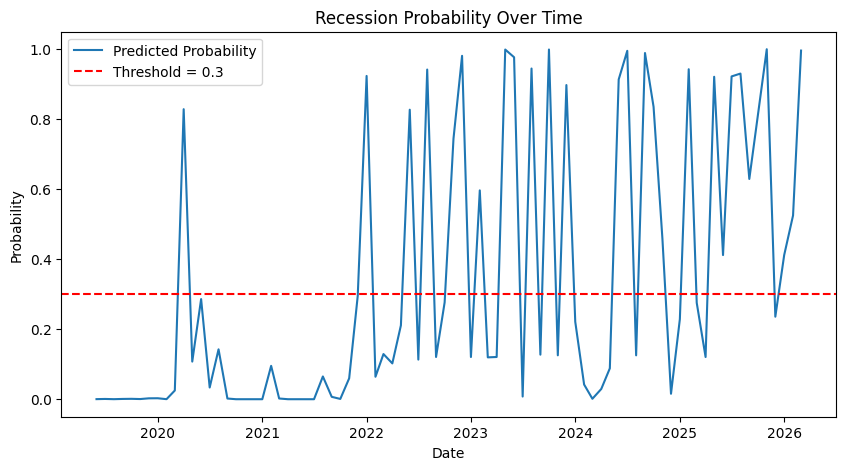

In [5]:
#Evaluation
def evaluate_model_threshold(name, model, X_test, y_test, threshold=0.3):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    print(f"\n{name} (threshold={threshold})")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Logistic Regression (scaled)
evaluate_model_threshold("Logistic Regression", lr, X_test_scaled, y_test, threshold=0.3)

# Random Forest
evaluate_model_threshold("Random Forest", rf, X_test, y_test, threshold=0.3)

# Gradient Boosting
evaluate_model_threshold("Gradient Boosting", gb, X_test, y_test, threshold=0.3)

def show_confusion_threshold(name, model, X_test, y_test, threshold=0.3):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    print(f"\n{name} (threshold={threshold})")
    print(confusion_matrix(y_test, y_pred))


show_confusion_threshold("Logistic Regression", lr, X_test_scaled, y_test, 0.3)
show_confusion_threshold("Random Forest", rf, X_test, y_test, 0.3)
show_confusion_threshold("Gradient Boosting", gb, X_test, y_test, 0.3)

probs = gb.predict_proba(X_test)[:, 1]
threshold = 0.3

plt.figure(figsize=(10,5))
plt.plot(data["date"].iloc[-len(probs):], probs, label="Predicted Probability")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold = 0.3")

plt.title("Recession Probability Over Time")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.show()